In [17]:
grid_data = [
    [3,2,2,3,2,2,3,2,1,1,1,1,1,1,2,3,2,2,3,2,2,3],
    [0,1,1,0,1,1,0,1,1,1,1,1,1,1,1,0,1,1,0,1,2,0],
    [1,1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,1,1,0,1,2,0],
    [1,2,2,1,1,2,2,1,0,0,1,1,1,1,0,1,2,2,1,1,1,0],
    [0,1,1,0,1,2,2,1,0,1,2,2,2,2,1,1,2,2,2,2,2,1],
    [0,1,1,0,1,2,1,0,1,2,2,2,1,1,1,1,3,3,1,1,1,1],
    [0,1,1,0,1,2,1,0,1,2,2,2,2,2,2,1,1,2,2,2,2,2],
    [0,0,0,0,0,1,1,0,0,1,1,0,1,1,1,0,0,0,0,1,1,1],
    [1,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,0,1,0,0,0,1],
    [4,2,1,2,3,2,2,4,3,2,1,1,2,3,4,2,2,3,2,1,2,4]
]

In [18]:
from z3 import Solver, Bool, And, Or, Not, sat

R = len(grid_data)
C = len(grid_data[0])

solver = Solver()

# Variables de segments
h_edges = [[Bool(f"h_{r}_{c}") for c in range(C)] for r in range(R + 1)]
v_edges = [[Bool(f"v_{r}_{c}") for c in range(C + 1)] for r in range(R)]

def pseudo_cardinality(bools, val):
    from itertools import combinations
    conds = []
    if val > 0:
        conds.append(Or([And(c) for c in combinations(bools, val)]))
    if val < len(bools):
        conds.append(And([Not(And(c)) for c in combinations(bools, val + 1)]))
    return And(conds) if conds else True

# CONTRAINTE UNIQUE : Satisfaire les chiffres des cases
for r in range(R):
    for c in range(C):
        cell_edges = [
            h_edges[r][c],      # Haut
            h_edges[r+1][c],    # Bas
            v_edges[r][c],      # Gauche
            v_edges[r][c+1]     # Droite
        ]
        solver.add(pseudo_cardinality(cell_edges, grid_data[r][c]))

# --- Résolution ---
print("Recherche d'une solution brute (uniquement basée sur les chiffres)...")
if solver.check() == sat:
    model = solver.model()
    print("\nSolution trouvée :\n")
    for r in range(R + 1):
        h_str = ""
        for c in range(C):
            h_str += "+"
            h_str += "───" if model.evaluate(h_edges[r][c]) else "   "
        h_str += "+"
        print(h_str)
        
        if r < R:
            v_str = ""
            for c in range(C + 1):
                v_str += "│" if model.evaluate(v_edges[r][c]) else " "
                if c < C:
                    v_str += f" {grid_data[r][c]} "
            print(v_str)
else:
    print("MÊME SANS CONTRAINTE, LE PROBLÈME EST IMPOSSIBLE.")
    print("Cela prouve à 100% que la grille de chiffres fournie contient une erreur.")

Recherche d'une solution brute (uniquement basée sur les chiffres)...

Solution trouvée :

+───+───+───+───+   +   +───+   +   +───+───+───+───+   +   +───+───+───+───+───+───+───+
│ 3 │ 2   2 │ 3 │ 2   2 │ 3 │ 2 │ 1   1   1   1   1   1 │ 2 │ 3 │ 2   2 │ 3 │ 2   2 │ 3 │
+   +   +   +   +───+───+   +   +   +   +   +   +   +   +   +   +   +   +   +   +   +   +
  0   1 │ 1   0   1   1   0   1 │ 1   1 │ 1   1 │ 1   1 │ 1   0   1 │ 1   0   1 │ 2   0  
+   +   +   +   +   +   +   +   +   +   +   +   +   +   +   +   +   +   +   +   +───+   +
  1 │ 1   1 │ 1   0   1   1   0   0   0   0   0   0   0   0   0   1 │ 1   0   1   2   0  
+   +   +   +   +   +───+───+   +   +   +   +   +   +   +   +   +   +   +   +───+───+   +
  1 │ 2 │ 2 │ 1   1   2   2   1   0   0   1 │ 1   1 │ 1   0   1 │ 2 │ 2   1   1   1   0  
+   +   +   +   +───+───+───+───+   +   +   +   +   +   +   +   +   +───+───+   +   +   +
  0   1   1   0   1   2   2   1   0   1   2 │ 2 │ 2 │ 2   1   1 │ 2   2   2 │ 2 │ 2 │ 1  
+   +───+

# 3 Calculs de "Rappel"

In [99]:
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

def precision(missing,wrong):
    return (total-missing-wrong)/(total-missing)

def recallGS(missing,wrong):
    return (total-missing)/total

def recallGB(missing,wrong):
    return (total-missing-wrong)/total

def recall(missing,wrong):
    return (total-missing-wrong)/(total-wrong)


def remplirHM(recall,total=150000):
    hm={}
    for pErr in range(0,100,5):
        errors=int(pErr/100*total)
    
        f={}
        for pMiss in range(0,105,5):
            missing=int(pMiss/100*errors)
            wrong=errors-missing
            # print(errors,missing,wrong)
            p=precision(missing,wrong)
            r=recall(missing,wrong)
            # print(f"{pMiss:.2%}\t{(2*p*r/(p+r)):.2%}")
            f[pMiss]=2*p*r/(p+r)
        hm[pErr]=f
    return hm

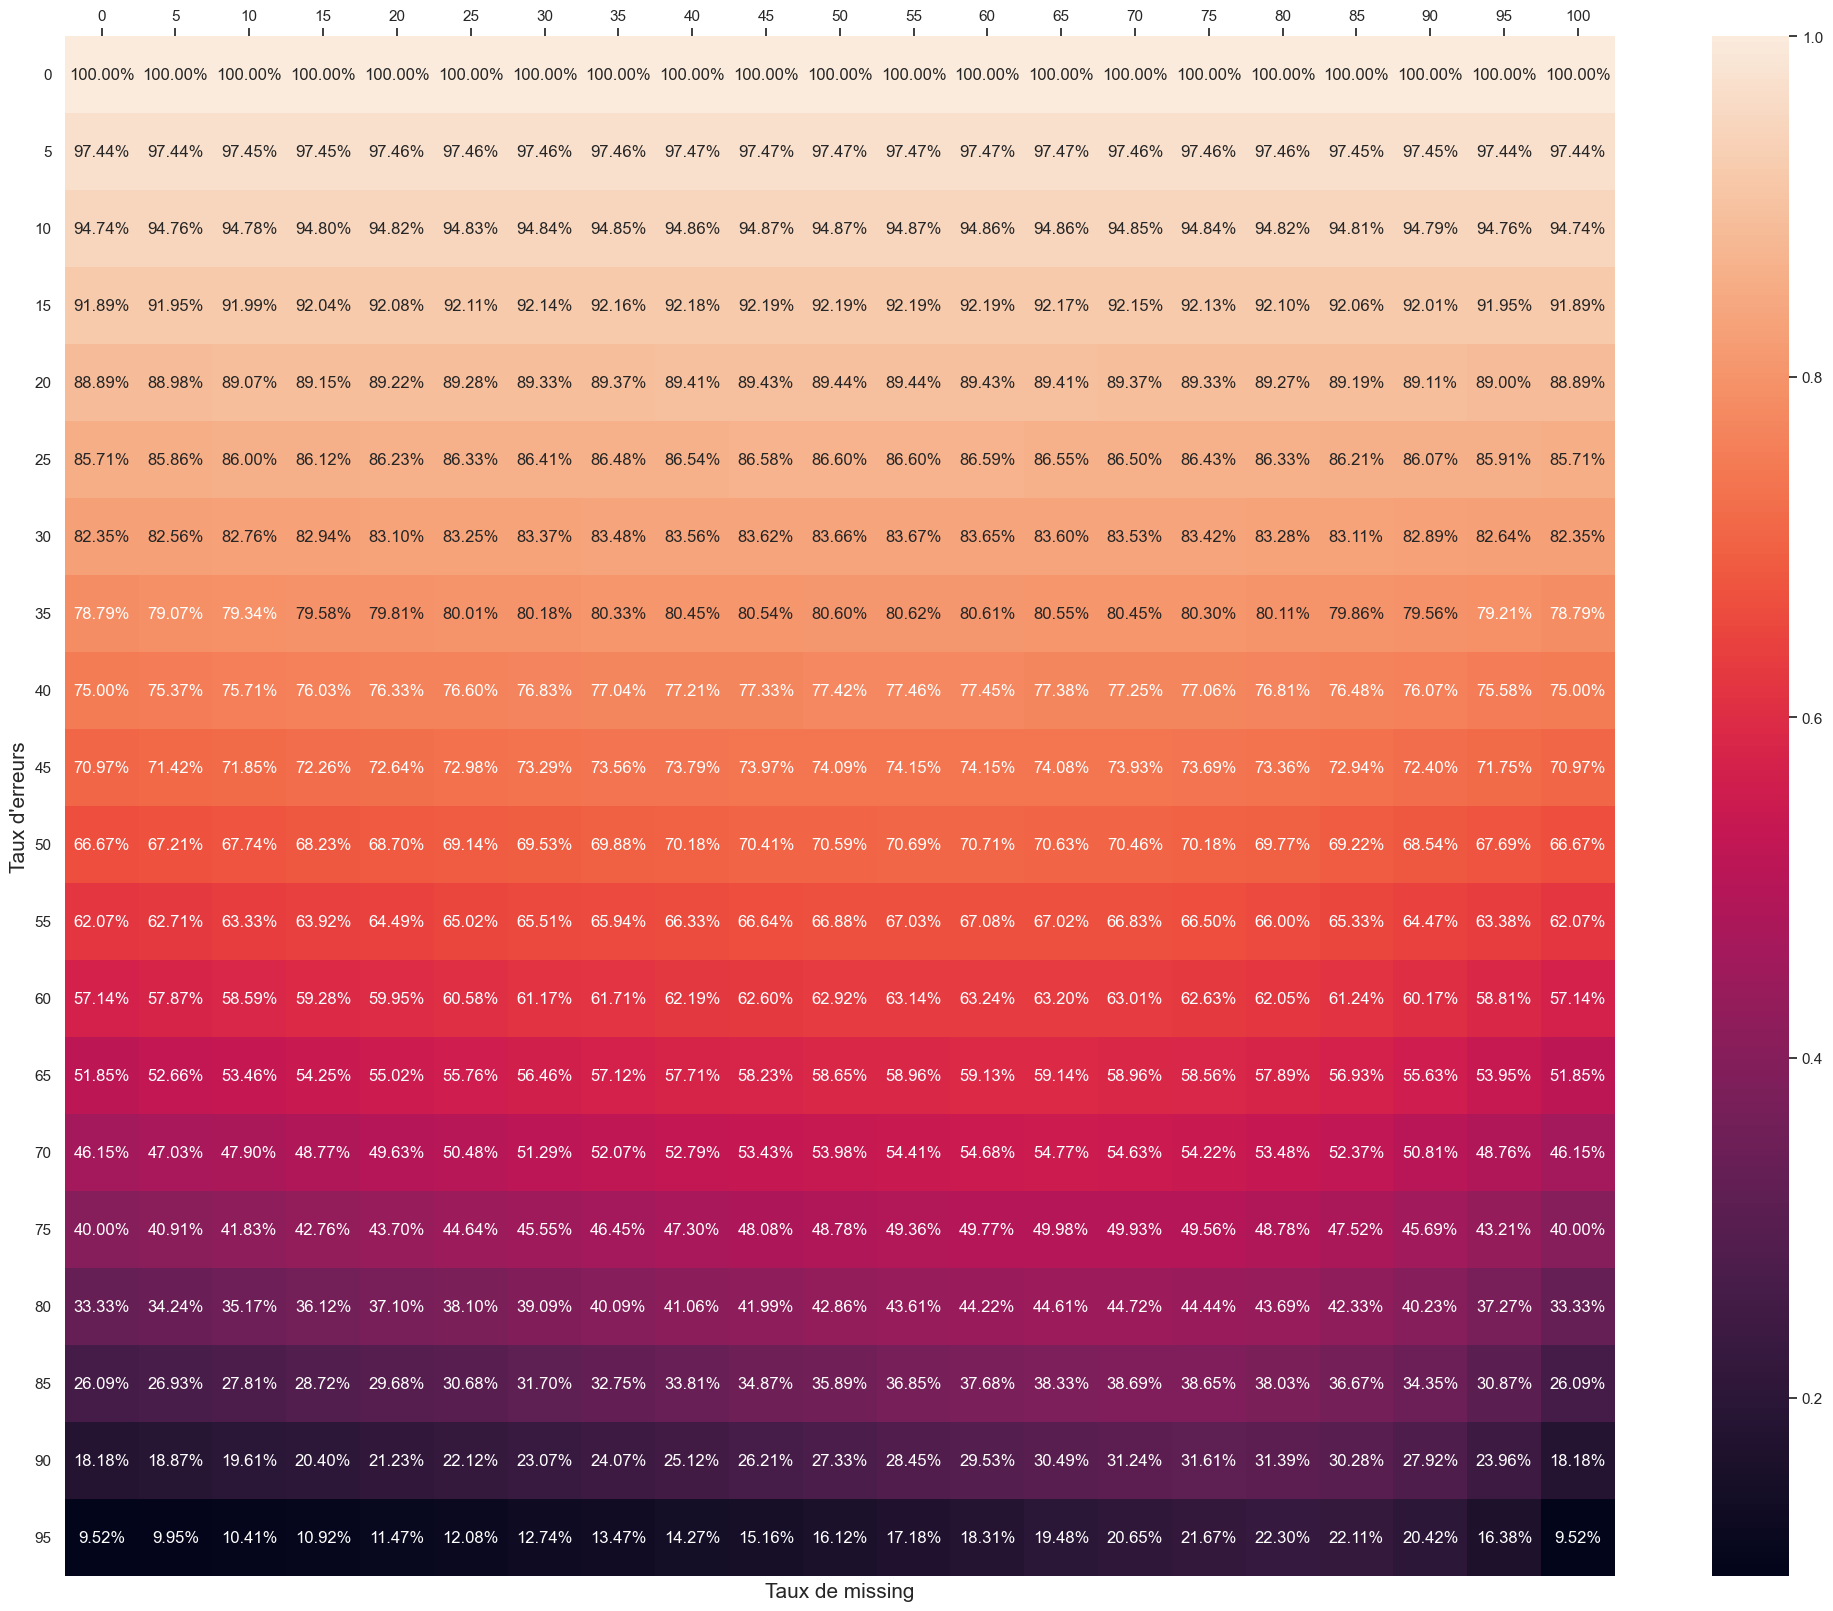

In [102]:
sns.set(rc={'figure.figsize':(25,20)})
hm=remplirHM(recallGS)
ax=sns.heatmap(pd.DataFrame.from_dict(hm,orient="index"),annot=True,fmt=".2%")
# ax.xaxis.tick_top()
ax.tick_params(axis='y', labelrotation=0)
plt.ylabel("Taux d'erreurs", fontsize = 15)
plt.xlabel("Taux de missing", fontsize = 15)
ax.xaxis.tick_top()


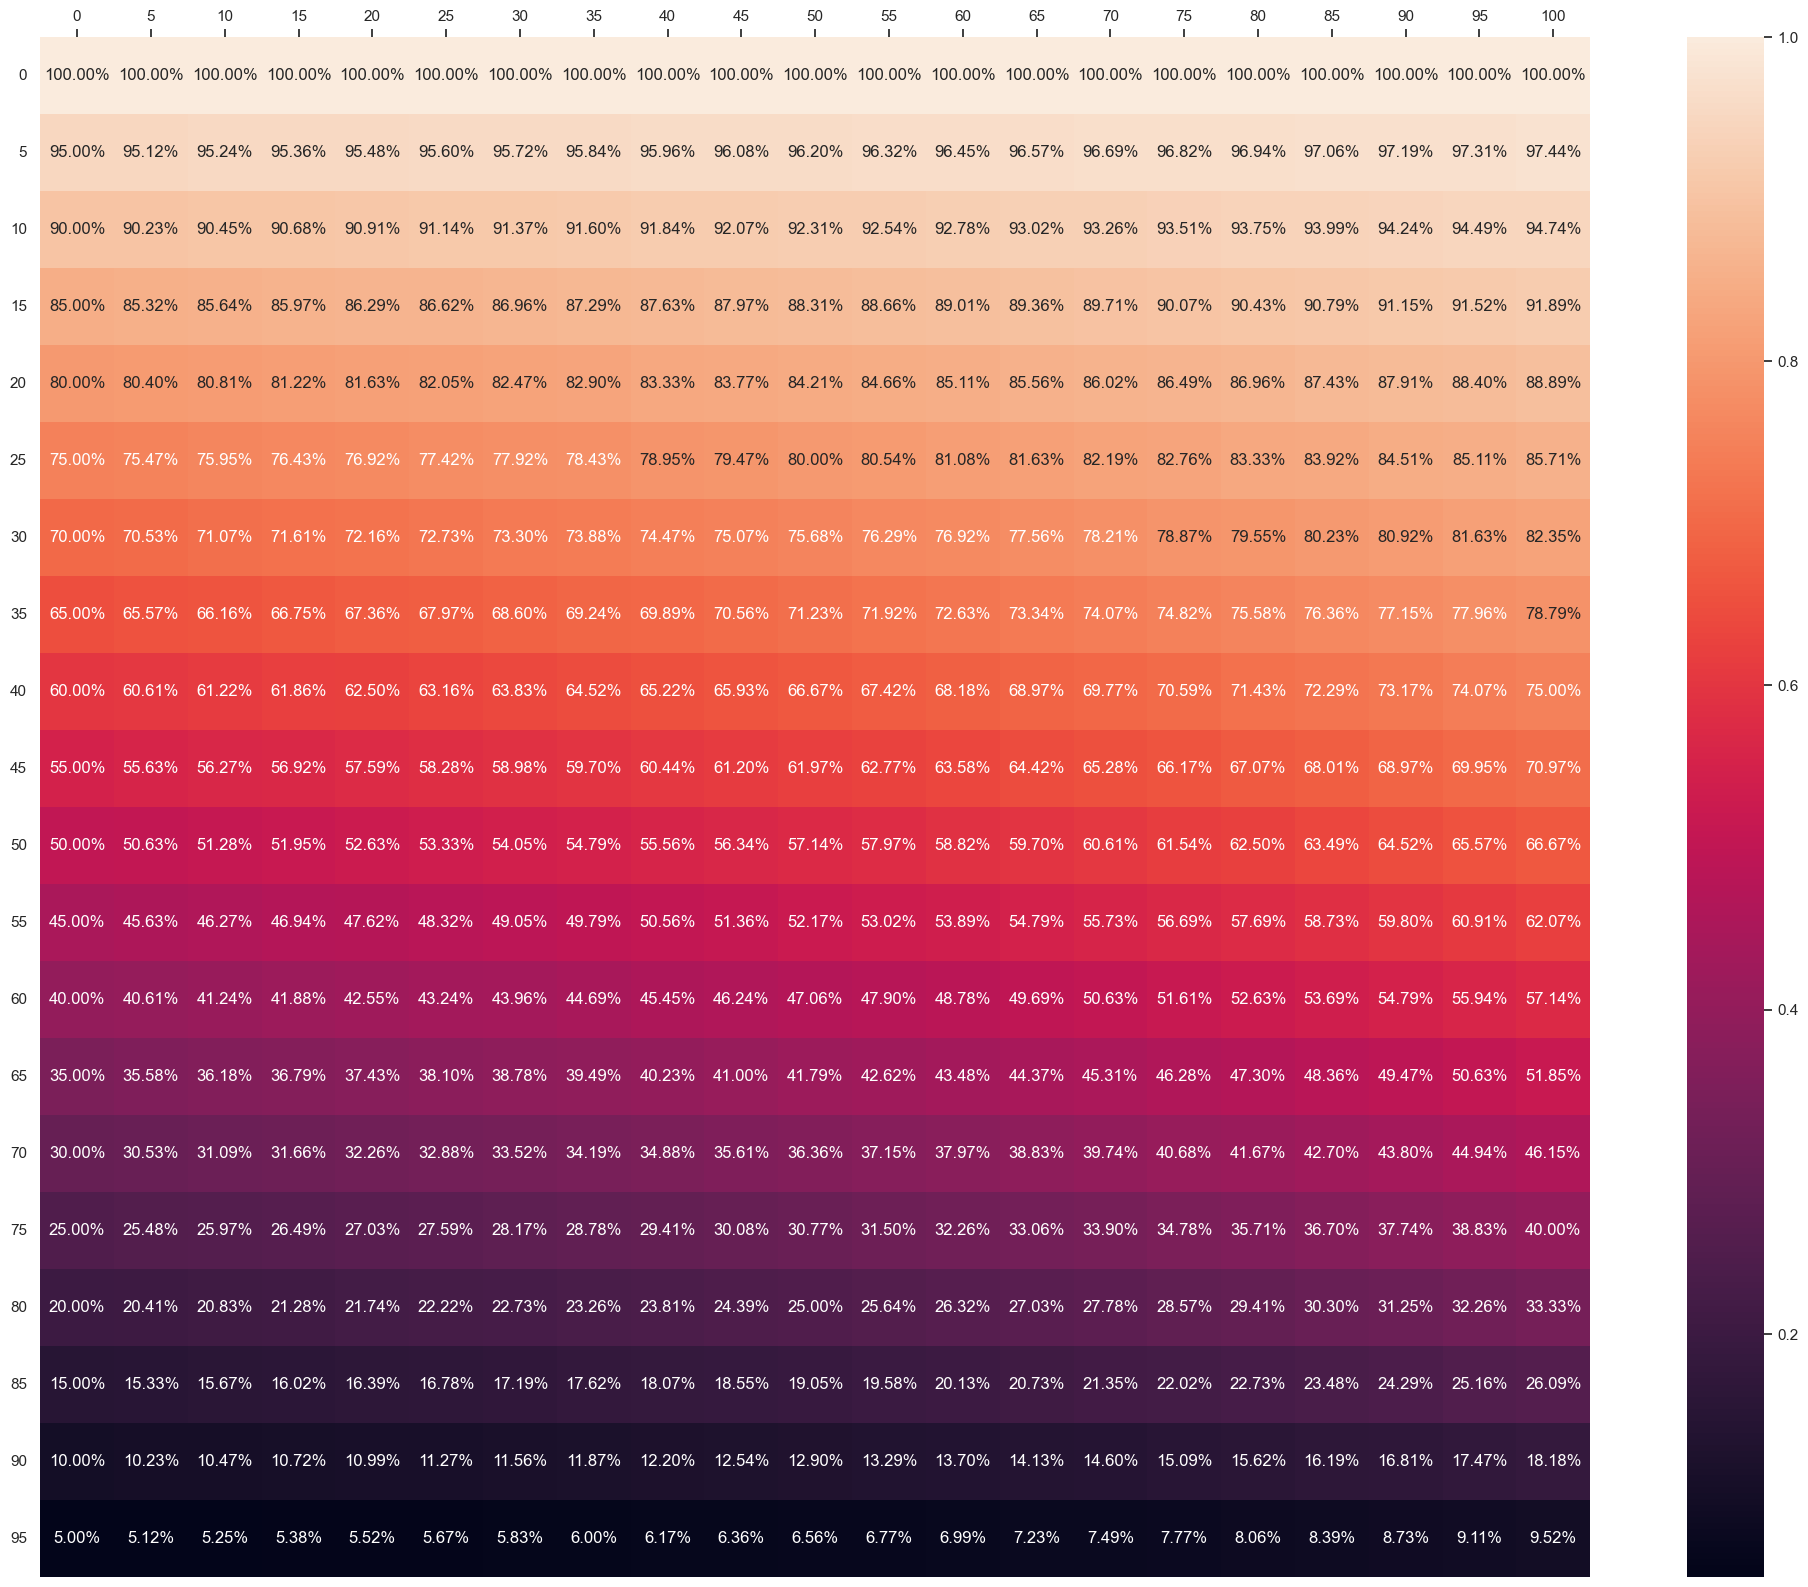

In [96]:
hm=remplirHM(recallGB)
ax=sns.heatmap(pd.DataFrame.from_dict(hm,orient="index"),annot=True,fmt=".2%")
ax.xaxis.tick_top()
ax.tick_params(axis='y', labelrotation=0)

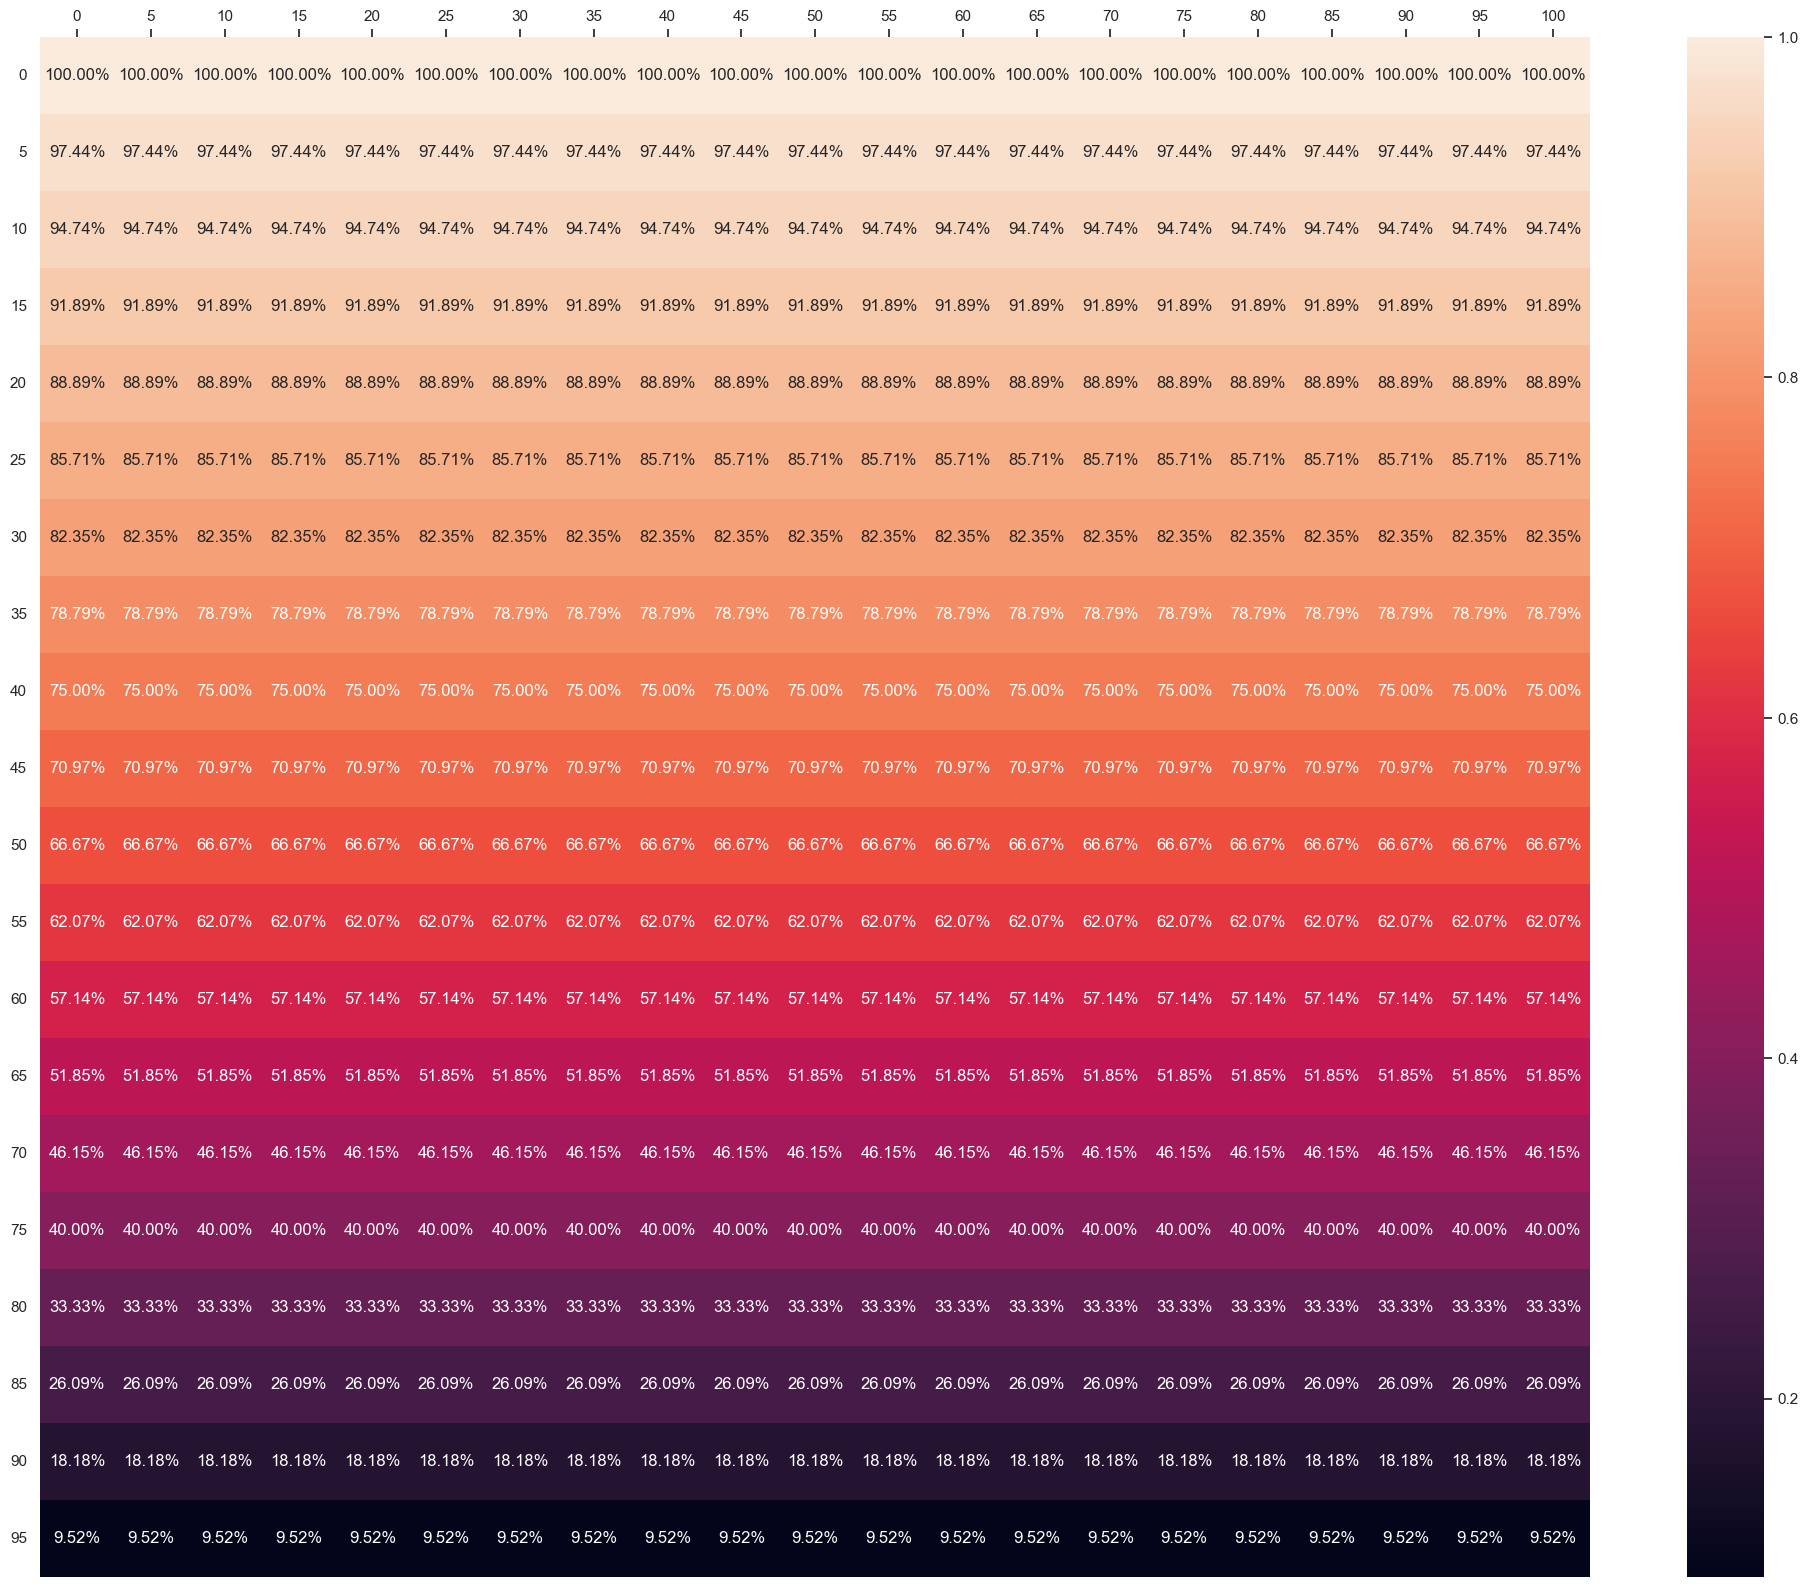

In [97]:
hm=remplirHM(recall)
ax=sns.heatmap(pd.DataFrame.from_dict(hm,orient="index"),annot=True,fmt=".2%")
ax.xaxis.tick_top()
ax.tick_params(axis='y', labelrotation=0)

# Word Error Rate
- missing = deletions
- wrong = substitution
- ??? = insertion
- correct+wrong+missing=N

$WER=\frac{S+D+I}{N}$